<a href="https://colab.research.google.com/github/SUDIPTO1903/AIR-QUALITY-INDEX/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [2]:
import pandas as pd

when u convole an image and a filter then the result of both of them is taht u get a feature map that helps in ur edge detection
there are various types of edge detectors vertical edge detector horizontal edge detector for vertical edge detector u use a certain type of filter  for horizotal edge detector u use a certain type of filter . Now each of the value basically, each value in the filter absically gets determind by back propogation of the cnn .


if the input image size is n*n and the filter size is m*m  tehn the feature map size will be (n-m+1)*(n-m+1)

we can visualize using
https://www.youtube.com/redirect?event=video_description&redir_token=QUFFLUhqa1lKYmdtTTZoT1cxWDZJNTE0RURMd1BkSnBvQXxBQ3Jtc0trWWZxRncwNXNPTzAyMzRtM3RjSUNoUEFCVWduZzc5UXh6bkFyRlllbUtvVVRWVV90c2E2azE5SUpFN3h2dFhHOURzWlNWblBmM0x3eU05c2VjU2Npdl8teFkzTm9Rbm56VUJFeGpEU196WFJMWXZuZw&q=https%3A%2F%2Fdeeplizard.com%2Fresource%2Fpavq7noze2&v=cgJx3GvQ5y8




Got it 👍 — **ONLY calculations**, cell-by-cell, for the **4×4 feature map** using **valid convolution**.

---

### Input (6×6)

Top 3 rows = all **0**
Bottom 3 rows = all **255**

### Kernel

```
-1  -1  -1
 0   0   0
 1   1   1
```

---

## Feature Map Cell Calculations

### Row 1 of Feature Map

**Cell (1,1)**

```
(-1·0) + (-1·0) + (-1·0)
+ (0·0)  + (0·0)  + (0·0)
+ (1·255)+ (1·255)+ (1·255)
= 0 + 0 + 765
= 765
```

**Cell (1,2)**

```
(-1·0) + (-1·0) + (-1·0)
+ (0·0)  + (0·0)  + (0·0)
+ (1·255)+ (1·255)+ (1·255)
= 765
```

**Cell (1,3)** → **765**
**Cell (1,4)** → **765**

---

### Row 2 of Feature Map

**Cell (2,1)**

```
(-1·0) + (-1·0) + (-1·0)
+ (0·255)+ (0·255)+ (0·255)
+ (1·255)+ (1·255)+ (1·255)
= 0 + 0 + 765
= 765
```

**Cell (2,2)** → **765**
**Cell (2,3)** → **765**
**Cell (2,4)** → **765**

---

### Row 3 of Feature Map

**Cell (3,1)**

```
(-1·0) + (-1·0) + (-1·0)
+ (0·255)+ (0·255)+ (0·255)
+ (1·255)+ (1·255)+ (1·255)
= 765
```

**Cell (3,2)** → **765**
**Cell (3,3)** → **765**
**Cell (3,4)** → **765**

---

### Row 4 of Feature Map

**Cell (4,1)**

```
(-1·255) + (-1·255) + (-1·255)
+ (0·255)  + (0·255)  + (0·255)
+ (1·255)  + (1·255)  + (1·255)
= -765 + 0 + 765
= 0
```

**Cell (4,2)** → **0**
**Cell (4,3)** → **0**
**Cell (4,4)** → **0**

---

## Final Feature Map (4×4)

```
765  765  765  765
765  765  765  765
765  765  765  765
 0    0    0    0
```

---

If you want, next I can:

* show **with padding**
* show **stride > 1**
* or explain **why this kernel detects horizontal edges** 🔥


BASICALLY,
DURING PADDING OR WHY TO ADD PADDING IS THAT THE LOGIC IS VERY SIMPLE

DURING CONVOLUTION OPERATION U ARE MISSING OUT OR LOOSING DATA AD THE IMAGE MATRIX WHICH WAS OF SIZE 6*6 GETS TURNED INTO 4*4  TAHTS WHY WHAT WE NEED TO DO


WE NEED TO ADD PADDING

AROUND THE IMAGE SO THAT WE DONT LOOSE CERTAIN DATA THE NEXT LOGIC IS THAT DURING CONVOLTUON MORE IMPORTANCE IS GIVEN TO THE PIXEL VALUES TAHT AR EPRESNET IN THE CENTER OF THE MATRIX AND LESS IMPORTANCE IS GIVEN TO THE VALUES THATA R EPRESENT AT THE CORNER OF THE MATRIX

WHAT IS PADDING?


INS IMPLE TERMS IT IS ADDING A ROW AND COLUMN INA LL FOUR SIDES WITH VALUE 0S SO THAT THE MATRIX DOESNT LOOSE IT S DATA

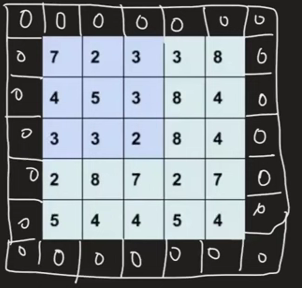

HERE U CAN SEE OUT HERE A LAYER  OF 0S IS ADDE DSO THAT THE FORMULA NOW BECOMES (N+2P-M+1)(N+2P-M+1)





In [3]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Conv2D,Flatten
from keras import Sequential
from keras.datasets import mnist

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu'))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [12]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 22, 22, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,002,698 (7.64 MB)

 Trainable params: 2,002,698 (7.64 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(2,2), activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(2,2), activation='relu'))
model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(2,2), activation='relu'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [15]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,770 (335.04 KB)

 Trainable params: 85,770 (335.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(1,1), activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(1,1), activation='relu'))
model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(1,1), activation='relu'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [17]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,231,498 (12.33 MB)

 Trainable params: 3,231,498 (12.33 MB)

 Non-trainable params: 0 (0.00 B)

Understood.
Here is **only the explanation**, no suggestions.

---

You used **`padding = "same"`**, but your output size still reduces because **stride is not 1**.

In convolution, **padding and stride have different roles**:

* **Padding = "same"**
  → ensures the kernel can be applied at the borders
  → it **does NOT guarantee same output size when stride > 1**

* **Stride = (2,2)**
  → the filter moves **2 pixels at a time**
  → this **skips positions**, reducing spatial size

---

### Exact rule being applied

For **`padding = "same"`**:

[
\text{Output size} = \left\lceil \frac{\text{Input size}}{\text{Stride}} \right\rceil
]

---

### Applying this to your model

**Input:** `28 × 28`

**After 1st Conv (stride = 2):**
[
\lceil 28 / 2 \rceil = 14
]
→ `(14, 14, 32)`

**After 2nd Conv:**
[
\lceil 14 / 2 \rceil = 7
]
→ `(7, 7, 32)`

**After 3rd Conv:**
[
\lceil 7 / 2 \rceil = 4
]
→ `(4, 4, 32)`

---

### Final clarification

* `padding="same"` keeps **border information**
* `stride=2` reduces **resolution**
* When both are used together, **stride dominates the output size**

That is why the output is **not the same size**, even though padding is `"same"`.


Yes. Here is the **plain text version** (safe to copy-paste, no symbols issue):

```
Output_size = floor((N + 2P - F) / S) + 1
```

Where:

```
N = input size (height or width)
F = kernel / filter size
S = stride
P = padding
```

Special cases:

VALID padding:

```
P = 0
Output_size = floor((N - F) / S) + 1
```

SAME padding (stride = 1):

```
P = (F - 1) / 2
Output_size = N
```

SAME padding (stride > 1):

```
Output_size = ceil(N / S)
```

This is the **convolution output size formula**.


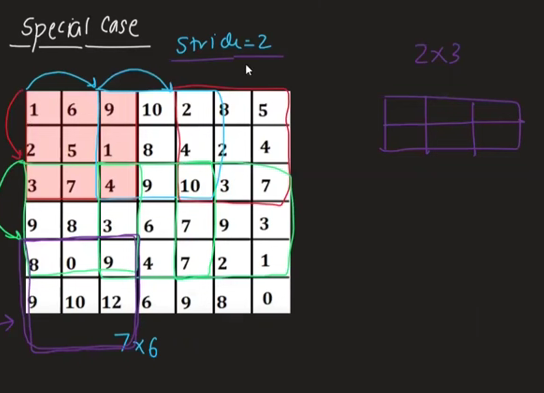


for the above type of  case u can see stride operations or we can say convoltuion operation for the last two rows wont be performed becuase of the missing data in the last row

**Simple logic, to the point: why strides are required**

* **Stride = how many pixels the filter moves each step**
* If stride = 1 → filter checks **every pixel**
* If stride > 1 → filter **skips pixels**

---

### Why we need strides

1. **Reduce image size**

   * Larger stride → smaller feature map
   * Helps control model size

2. **Reduce computation**

   * Fewer positions to compute
   * Faster training and inference

3. **Capture broader patterns**

   * Skipping pixels forces the model to look at **larger regions**
   * Useful for high-level features

4. **Downsampling without pooling**

   * Strides can replace max-pooling
   * Learned downsampling, not fixed

---

### One-line logic

> **Strides are used to control how much spatial information is kept vs skipped.**

That’s the core reason.


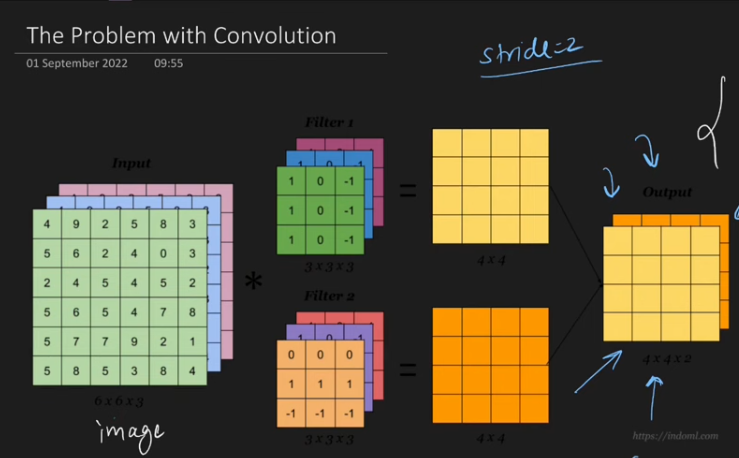  



abscally the problem out here is suppose u take  a 228 228 3 image and then u decide to perofrm a convoltuion operation out there

and suppose u apply 100 filters then the size of ur feature map will be exteremy evry large


now one way tor educe the size fo the featur emap is to increase the strides but a better way for this is pooling



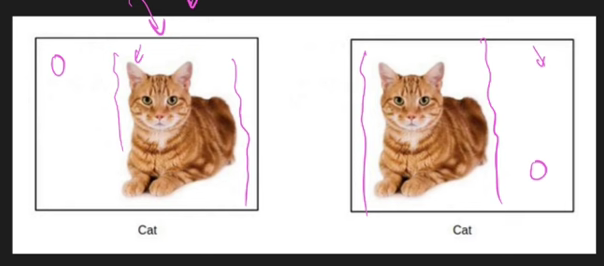

oaky let me sum up

EDIT WHERE I AM WRONG OR U WANT TOA DD ANYTUHING

INITALLY  THE I TAKE THE FEATURE SUPPOSE

EAR OF THE CAT OKAY ITS
TOWARDS RIGHT IN FIRST IMAGE TOWARDS LEFT INSECOND IMAGE NOW WHAT HAPPENS AFTER APPKYING CONVOLTUION OPERATION ON BOTH THE IMAGES
NOW WHAT WILL HAPPEN IS THAT

U WILL SEE THAT THE SAME EAR WILL HAVE DIFFERNT VALUES FOR FIRST IMAGE  EAR IS AT RIGHT
FOR SECOND IMAGE, EAR IS AT LEFT NOW

AFTER APPLYING CONVOLUTION LAYER ,
WHEN THE LAYER IS FLATTEND FOR THE SAME ATTRIBUTE EAR

DIFFERNET INDEX VALUES WILL BE PRESNT ONE FOR THE LEFT ONE
ANOTEHR FR THE RIGHT ONE


BUT ISSUE IS THE FEATURE IS EAR WHICH SHOULD BE LOCATION INDEPENDENT
BUT ITY BECOMES LOCATION DEPENDENT

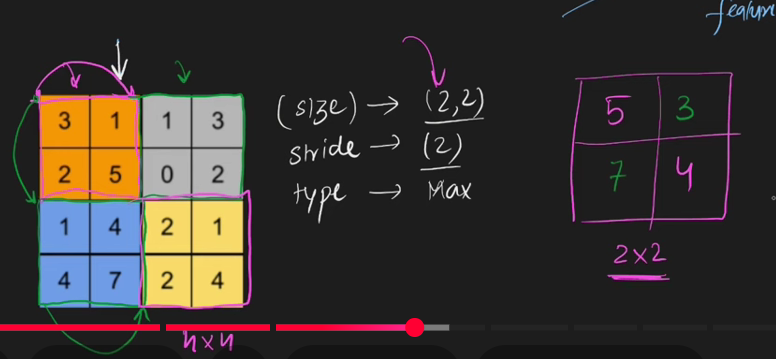
IN TEH FEATURE MAP OUT THERE

AT FIRST UR TASK IS T DEFINE THE SIZE OF THE KERNEL OUT THERE ,

HERE WE HAVE TAKEN A 2 CROSS 2 MATRIX NOW DEFINE THE STRIDES,
AND HERE THE TYPE IS MAX
NOW IN FIRST SQAURE OUT OF 3 2 1 5 , 5 IS SEELECTED
NOW IN SECOND SQUARE OUT OF 1  3 0 2,3 IS SELECTED
NOW IN THRID SQUARE OUT OF 1 4 4 7 , 7 IS SELECTED
NOW IN 4TH SQUARE,2 1 2 4, 4 IS SELECTED

AND A FINAL POOLING MATRIX SI FORMED WHICH CAPTURES ALL THE MAJOR FETAURES


LOW LEVEL FEATURES WILL BE ELINIMATED

IN CASE OF MIN POOLING WHAT HAPPENS IS THAT U ATKWE THE MIN VALUE OF OF 2 CROSS 2 IN MAX U TAKE MAX VALUE AND AVERAGE U TAKE THE AVERAGE VALUE




AND IN CASE OF GLOBAL MAX POOLING U TAKE OUT OF THE WHOLE FEATURE MAP ONLY ONE VALUE THATS UIT '

In [18]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from keras import Sequential
from keras.datasets import mnist

In [19]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [20]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,386 (442.91 KB)

 Trainable params: 113,386 (442.91 KB)

 Non-trainable params: 0 (0.00 B)

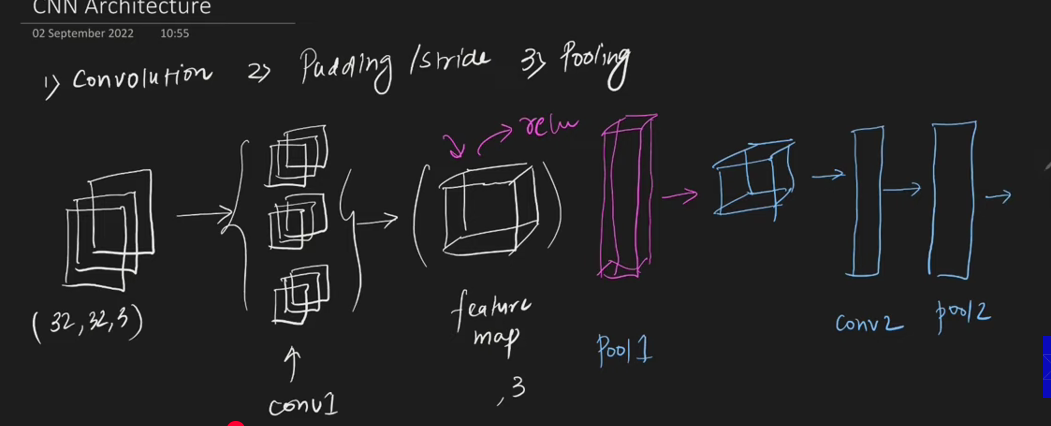


BASICALLY WHAT IS HAPPENEING IN CASE OF THE ARCHICTURE

1. U HAVE AN RBG IMAGE NOW U APPLY 3 FILTERS ON IT

2.AFTER THE CONVVOLTUION, FOR 3 FILTERS, ONE FEATURE MAP IS GOT FROM THE RESULT OUT THERE

3.PASS THE FEATRUE MAP THROUGH A POOLING LAYER,AND THEN U GET THE OUTPUT OUT THERE.

4.AFTER THAT U FLATTEN IT , AND THEN PASS THROUGH A FULLY CONNECTED LAYER THEN OUT PUT IF BINARY CLASS THEN SIGMOID OTHER WISE SOFTMAX



In [22]:
#LE NET ARCHICTTRUE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(
    filters=6,
    kernel_size=(5, 5),
    padding='valid',
    activation='tanh',
    input_shape=(32, 32, 1)
))

model.add(AveragePooling2D(
    pool_size=(2, 2),
    strides=2,
    padding='valid'
))

model.add(Conv2D(
    filters=16,
    kernel_size=(5, 5),
    padding='valid',
    activation='tanh'
))

model.add(AveragePooling2D(
    pool_size=(2, 2),
    strides=2,
    padding='valid'
))

model.add(Flatten())

model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load image
img = image.load_img(
    '/content/kitten-4611189_1280.jpg',
    target_size=(200, 200)
)

# Display image
plt.imshow(img)
plt.axis('off')

ImportError: cannot import name 'ImageDataGenerator' from 'keras.preprocessing.image' (/usr/local/lib/python3.12/dist-packages/keras/preprocessing/image/__init__.py)

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

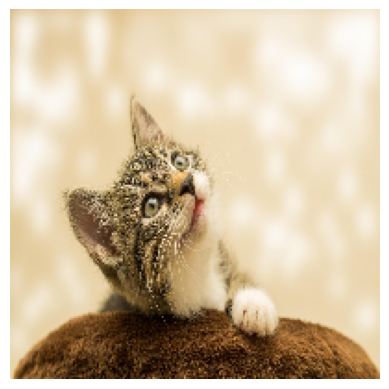

In [24]:
from keras.preprocessing import image
import matplotlib.pyplot as plt

# Load image
img = image.load_img(
    '/content/kitten-4611189_1280.jpg',
    target_size=(200, 200)
)

# Display image
plt.imshow(img)
plt.axis('off')


I’ll explain **each parameter in very simple, practical terms**, **using your kitten image as reference** 🐱
(No code, no extra theory.)

---

### `rotation_range = 40`

* The image can be **rotated left or right**
* For your kitten:

  * The cat may **tilt its head sideways**
  * Like the kitten is looking at something at an angle

---

### `width_shift_range = 0.2`

* The image can move **left or right**
* `0.2` = **20% of image width**
* For your kitten:

  * The kitten may shift **towards left or right edge**
  * Some background appears on the opposite side

---

### `height_shift_range = 0.2`

* The image can move **up or down**
* For your kitten:

  * The kitten may move **higher or lower**
  * Part of the head or paws may go closer to the border

---

### `shear_range = 0.2`

* The image is **slanted or skewed**
* For your kitten:

  * The kitten may look **slightly stretched diagonally**
  * Like the image is pushed from one corner

---

### `zoom_range = 0.2`

* The image can **zoom in or zoom out**
* For your kitten:

  * Zoom in → kitten’s face looks **bigger**
  * Zoom out → more background visible

---

### `horizontal_flip = True`

* The image can be **mirrored left ↔ right**
* For your kitten:

  * The kitten faces the **opposite direction**
  * Left paw becomes right paw

---

### `fill_mode = 'nearest'`

* What happens to **empty areas** created by transformations
* For your kitten:

  * Missing pixels are filled using **nearby background pixels**
  * No black holes or blank areas

---

### One-line summary

> **These parameters create slightly changed versions of the same kitten image so the model learns the cat no matter how it appears or where it is.**

If you want next:

* I can show **before vs after for each transform**
* Or explain **why this helps reduce overfitting**
* Or explain **which ones are most important and why**


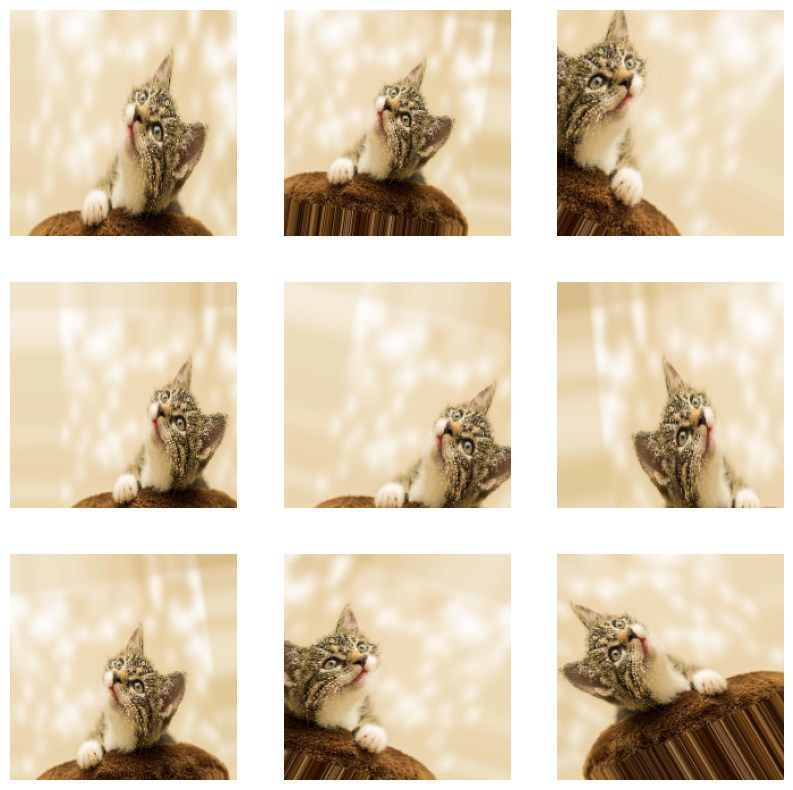

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Load image
img = load_img(
    '/content/kitten-4611189_1280.jpg',
    target_size=(200, 200)
)

# Convert image to array
x = img_to_array(img)
x = np.expand_dims(x, axis=0)  # shape (1, 200, 200, 3)

# Image augmentation settings
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate and display images
plt.figure(figsize=(10, 10))

i = 1
for batch in datagen.flow(x, batch_size=1):
    plt.subplot(3, 3, i)
    plt.imshow(batch[0].astype('uint8'))
    plt.axis('off')
    i += 1
    if i > 9:   # show 9 images
        break

plt.show()


In [26]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sududead","key":"879faa36d046e84402dc7cc13b0ef397"}'}

In [27]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [28]:
!kaggle datasets download -d username/Fruits and Vegetables Image Recognition Dataset

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,config}
              ...
kaggle: error: unrecognized arguments: Vegetables Image Recognition Dataset


In [30]:
!kaggle datasets download -d username/fruit-and-vegetable-image-recognition


403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/username/fruit-and-vegetable-image-recognition


In [31]:
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition


Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
 99% 1.97G/1.98G [00:26<00:00, 78.0MB/s]
100% 1.98G/1.98G [00:27<00:00, 78.9MB/s]


In [32]:
!unzip fruit-and-vegetable-image-recognition.zip


Archive:  fruit-and-vegetable-image-recognition.zip
  inflating: test/apple/Image_1.jpg  
  inflating: test/apple/Image_10.jpg  
  inflating: test/apple/Image_2.jpg  
  inflating: test/apple/Image_3.jpg  
  inflating: test/apple/Image_4.jpg  
  inflating: test/apple/Image_5.jpg  
  inflating: test/apple/Image_6.JPG  
  inflating: test/apple/Image_7.jpg  
  inflating: test/apple/Image_8.jpg  
  inflating: test/apple/Image_9.jpg  
  inflating: test/banana/Image_1.jpg  
  inflating: test/banana/Image_10.jpg  
  inflating: test/banana/Image_2.jpg  
  inflating: test/banana/Image_3.jpg  
  inflating: test/banana/Image_4.jpg  
  inflating: test/banana/Image_5.jpg  
  inflating: test/banana/Image_6.jpg  
  inflating: test/banana/Image_8.jpg  
  inflating: test/banana/Image_9.jpg  
  inflating: test/beetroot/Image_1.jpg  
  inflating: test/beetroot/Image_10.jpg  
  inflating: test/beetroot/Image_2.jpg  
  inflating: test/beetroot/Image_3.jpg  
  inflating: test/beetroot/Image_4.jpg  
  inflati

In [33]:
!ls


fruit-and-vegetable-image-recognition.zip  sample_data	validation
kaggle.json				   test
kitten-4611189_1280.jpg			   train


In [34]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:

import tensorflow as tf
import matplotlib.pyplot as plt


In [2]:
%cd /content/Fruit\ and\ Vegetable\ Image\ Recognition


[Errno 2] No such file or directory: '/content/Fruit and Vegetable Image Recognition'
/content


In [3]:
# Step 1: Install kagglehub
!pip install -q kagglehub

# Step 2: Import kagglehub
import kagglehub
import os

# Step 3: Download dataset programmatically (no manual download)
dataset_path = kagglehub.dataset_download(
    "kritikseth/fruit-and-vegetable-image-recognition"
)

print("Dataset stored at:", dataset_path)

# Step 4: Explore dataset
for root, dirs, files in os.walk(dataset_path):
    print(root)
    break


100%|██████████| 1.98G/1.98G [01:34<00:00, 22.6MB/s]

Extracting files...


Dataset stored at: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8
/root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8
